In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import os

plt.style.use('seaborn-v0_8-whitegrid')

os.makedirs("project4drawdowns_charts", exist_ok=True)


end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL", "KO", "^GSPC", "NVDA", "GC=F"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,GC=F,KO,NVDA,^GSPC
Date,,,,,
2021-06-07,122.721268,1896.800049,48.283207,17.574705,4226.520020
2021-06-08,123.540039,1892.199951,47.947197,17.413111,4227.259766
2021-06-09,123.920212,1893.199951,47.800728,17.318577,4219.549805
2021-06-10,122.925964,1894.199951,48.171204,17.385174,4239.180176
2021-06-11,124.134644,1877.400024,48.386600,17.784510,4247.439941
...,...,...,...,...,...
2026-05-28,312.510010,4499.299805,80.410004,214.250000,7563.629883
2026-05-29,312.059998,4560.500000,79.010002,211.139999,7580.060059
2026-06-01,306.309998,4475.200195,78.639999,224.360001,7599.959961


In [15]:
returns = df.pct_change().dropna()
returns

C:\Users\yashr\AppData\Local\Temp\ipykernel_25640\119691768.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df.pct_change().dropna()


Ticker,AAPL,GC=F,KO,NVDA,^GSPC
Date,,,,,
2021-06-08,0.006672,-0.002425,-0.006959,-0.009195,0.000175
2021-06-09,0.003077,0.000528,-0.003055,-0.005429,-0.001824
2021-06-10,-0.008023,0.000528,0.007750,0.003845,0.004652
2021-06-11,0.009833,-0.008869,0.004471,0.022970,0.001948
2021-06-14,0.024578,-0.007138,-0.003409,0.010855,0.001815
...,...,...,...,...,...
2026-05-28,0.005340,0.011647,-0.014825,0.007761,0.005754
2026-05-29,-0.001440,0.013602,-0.017411,-0.014516,0.002172
2026-06-01,-0.018426,-0.018704,-0.004683,0.062612,0.002625


Ticker
AAPL      2.528168
GC=F      2.339045
KO        1.631209
NVDA     12.219266
^GSPC     1.787210
Name: 2026-06-03 00:00:00, dtype: float64


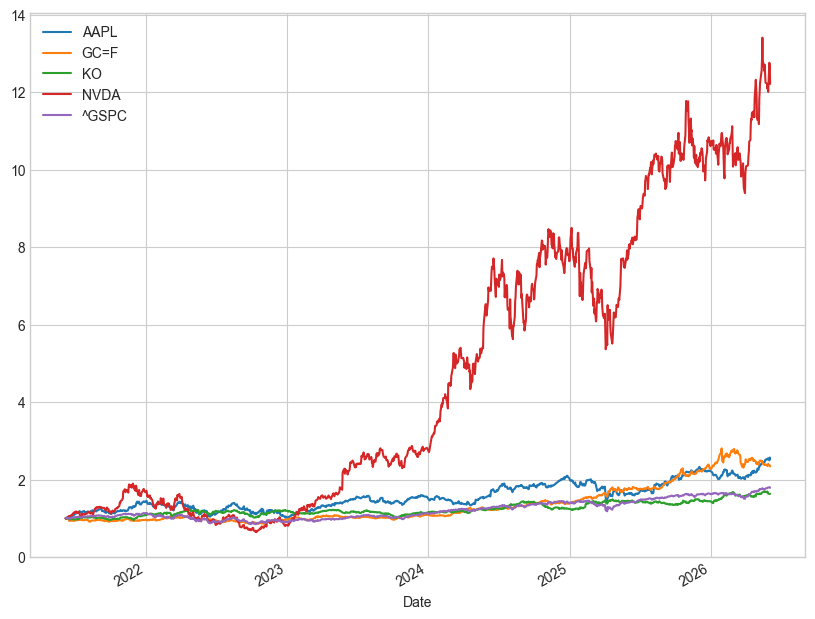

In [16]:
wealthindex = (1+returns).cumprod()
wealthindex
y = wealthindex.iloc[-1]
lastdate = wealthindex.index[-1]
print(y)
wealthindex.plot(figsize=(10,8))
sorted_assets = y.sort_values().index

plt.legend()


In [17]:
table = y.reset_index()
table.columns = ["Asset", "Final Wealth"]
table["Returns (%)"] = (table['Final Wealth'] - 1) * 100
df_wealth = pd.DataFrame(table)
df_wealth = df_wealth.round(2)
df_wealth.set_index('Asset', inplace=True)
df_wealth

,Final Wealth,Returns (%)
Asset,,
AAPL,2.53,152.82
GC=F,2.34,133.90
KO,1.63,63.12
NVDA,12.22,1121.93
^GSPC,1.79,78.72


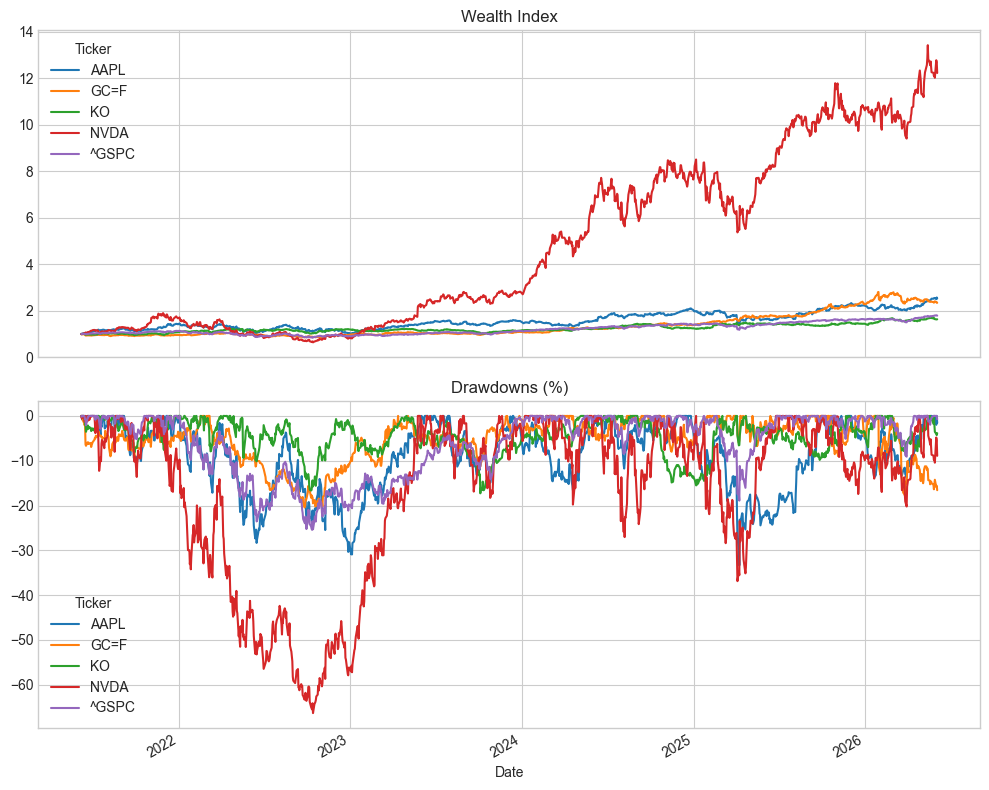

In [18]:
peaks = wealthindex.cummax()
drawdowns = (wealthindex - peaks) / peaks

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8),sharex = True)
wealthindex.plot(ax=ax1)
ax1.set_title("Wealth Index")
(drawdowns*100).plot(ax=ax2)
ax2.set_title("Drawdowns (%)")

plt.tight_layout()
plt.savefig("project4drawdowns_charts/wealthindex_drawdowns.png")
plt.show()

In [19]:
drawdowns.min()

Ticker
AAPL    -0.333605
GC=F    -0.204304
KO      -0.172748
NVDA    -0.663351
^GSPC   -0.254251
dtype: float64

In [20]:
recovery_times = {}

for asset in wealthindex.columns:
    wealth = wealthindex[asset]
    peak = wealth.cummax()
    drawdown = (wealth - peak)/peak

    worst = drawdown.idxmin()
    previous_peak = peak.loc[worst]
    peak_date = wealth.loc[:worst][wealth.loc[:worst] >= previous_peak].index.max()

    recovery_date = wealth.loc[worst:][wealth.loc[worst:] >= previous_peak].index.min()
    if pd.notna(recovery_date):
        recovery_times[asset] = (recovery_date - peak_date).days
        
df = pd.Series(recovery_times).sort_values(ascending=False)
df

KO       746
^GSPC    746
NVDA     542
GC=F     401
AAPL     298
dtype: int64

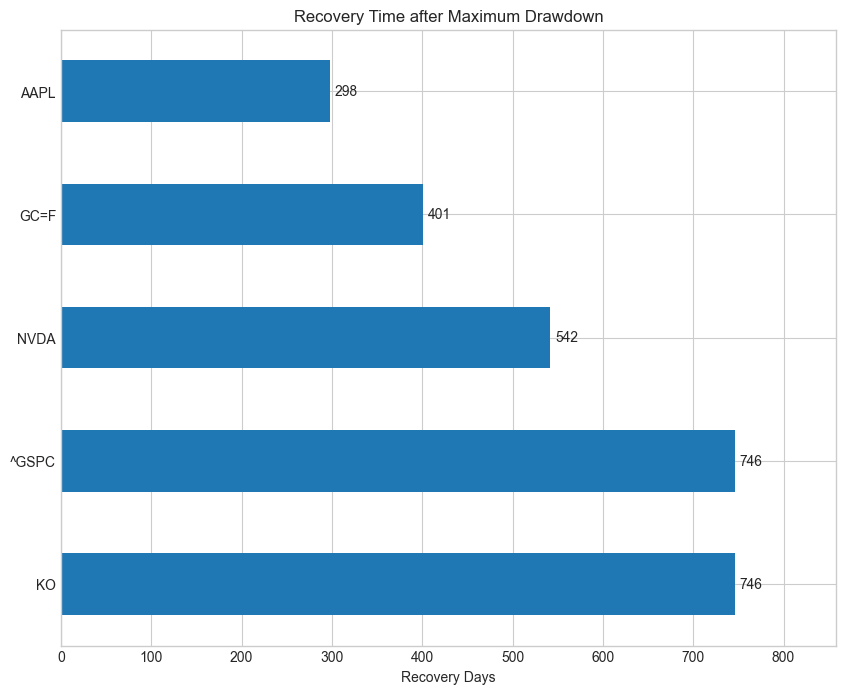

In [21]:
df.plot(kind='barh', figsize=(10,8))
plt.xlabel('Recovery Days')
plt.title('Recovery Time after Maximum Drawdown')

for i, value in enumerate(df.values):
    plt.text(value + 5, i, str(value), va='center')

plt.xlim(right=df.values.max()*1.15)

plt.savefig("project4drawdowns_charts/recovery_times.png")


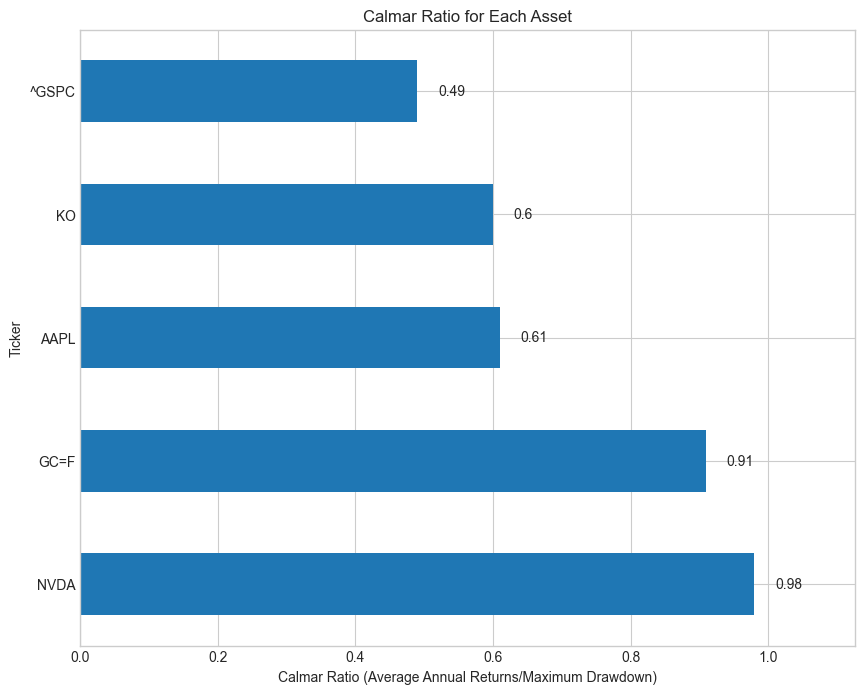

In [22]:
days_elapsed = (wealthindex.index[-1] - wealthindex.index[0]).days
years_elapsed = days_elapsed/365.25
cagr = wealthindex.iloc[-1]**(1/years_elapsed) - 1
calmar = cagr/abs(drawdowns.min())
calmar = calmar.sort_values(ascending=False).round(2)

calmar.plot(kind='barh', figsize=(10,8))

for i, value in enumerate(calmar.values):
    plt.text(value + 0.03, i, str(value), va='center')
plt.xlim(right = calmar.max()*1.15)

plt.xlabel('Calmar Ratio (Average Annual Returns/Maximum Drawdown)')
plt.title('Calmar Ratio for Each Asset')
    
plt.savefig("project4drawdowns_charts/calmar_ratio.png")

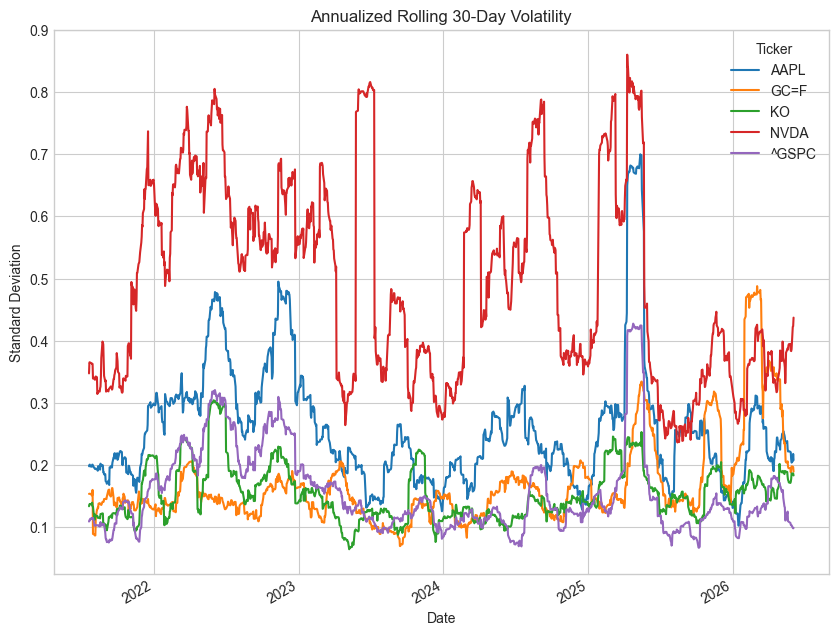

In [23]:
rolling_volatility = returns.rolling(30).std().dropna()
(rolling_volatility*np.sqrt(252)).plot(figsize=(10,8))
plt.title("Annualized Rolling 30-Day Volatility")
plt.ylabel('Standard Deviation')

plt.savefig("project4drawdowns_charts/rolling_volatility.png")

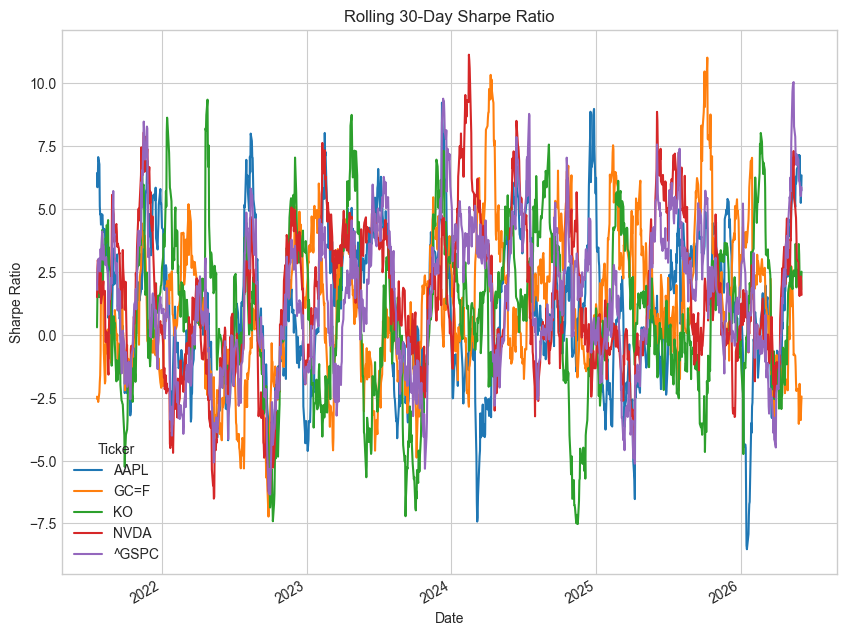

In [24]:
sharpe = returns.rolling(30).mean()/returns.rolling(30).std()
sharpe = sharpe.dropna()
sharpe = sharpe*np.sqrt(252)

sharpe.plot(figsize=(10,8))
plt.title('Rolling 30-Day Sharpe Ratio')
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig("project4drawdowns_charts/rolling_sharpe.png")



In [25]:
summary = pd.DataFrame({
    "CAGR (%)": (cagr * 100),
    "Max Drawdown (%)": (drawdowns.min() * 100),
    "Recovery Days": pd.Series(recovery_times),
    "Calmar Ratio": calmar
}).round(2)
summary

,CAGR (%),Max Drawdown (%),Recovery Days,Calmar Ratio
AAPL,20.45,-33.36,298,0.61
GC=F,18.58,-20.43,401,0.91
KO,10.31,-17.27,746,0.60
NVDA,65.21,-66.34,542,0.98
^GSPC,12.35,-25.43,746,0.49
